<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1 TS1: Síntesis y operaciones de señales
#### Rodriguez Lucas Ignacio





## Objetivos
* **Sintetizar señales discretas operativas:** Generación de señales armónicas, ruido estocástico (Gaussiano y Uniforme) y pulsos rectangulares en un entorno digital con $N = 1000$ muestras.
* **Analizar el espectro mediante la DFT:** Representación y evaluación del módulo de la Transformada Discreta de Fourier ($|X(f)|$), analizando la densidad espectral de potencia y verificando la ausencia de fuga espectral  bajo condiciones de sintonía.


---

## Marco Teórico y Consideraciones Principales

1. **Condición de Muestreo:** Para la síntesis de señales senoidales de $f_0 = 2\text{ kHz}$, se establece una frecuencia de muestreo de $f_s = 20\text{ kHz}$ ($10\text{ puntos/período}$), garantizando el cumplimiento holgado del teorema de Nyquist-Shannon.
2. **Propiedades de las Señales Estocásticas:** La comparación entre ruido Gaussiano y Uniforme demuestra que, para un mismo nivel de potencia y media nula, sus módulos de DFT presentan distribuciones de densidad espectral planas (ruido blanco), diferenciándose únicamente en sus Funciones de Densidad de Probabilidad (PDF) en el tiempo.



## Ejercicio 1.1: Señal Sinusoidal de 2 kHz

### Consideraciones de Muestreo
Para sintetizar una señal senoidal de frecuencia $f_0 = 2\text{ kHz}$ garantizando al menos 10 muestras por período, definimos la frecuencia de muestreo $f_s$ como:
$$f_s = 10 \cdot f_0 = 20\text{ kHz} \implies T_s = \frac{1}{f_s} = 50\ \mu\text{s}$$

Con $N = 1000$ muestras, el tiempo total de observación es $T_{obs} = N \cdot T_s = 50\text{ ms}$, lo que corresponde a 100 períodos completos de la senoidal.

### Resolución Espectral
La resolución espectral de la DFT viene dada por:
$$\Delta f = \frac{f_s}{N} = \frac{20000\text{ Hz}}{1000} = 20\text{ Hz}$$

Como $f_0 = 2000\text{ Hz}$ es un múltiplo entero exacto de $\Delta f$ ($k = \frac{2000}{20} = 100$), **no existe fuga espectral (*spectral leakage*)**. Toda la energía de la señal se concentra de forma pura en los bins $k = 100$ y $k = 900$ (frecuencia negativa equivalente).

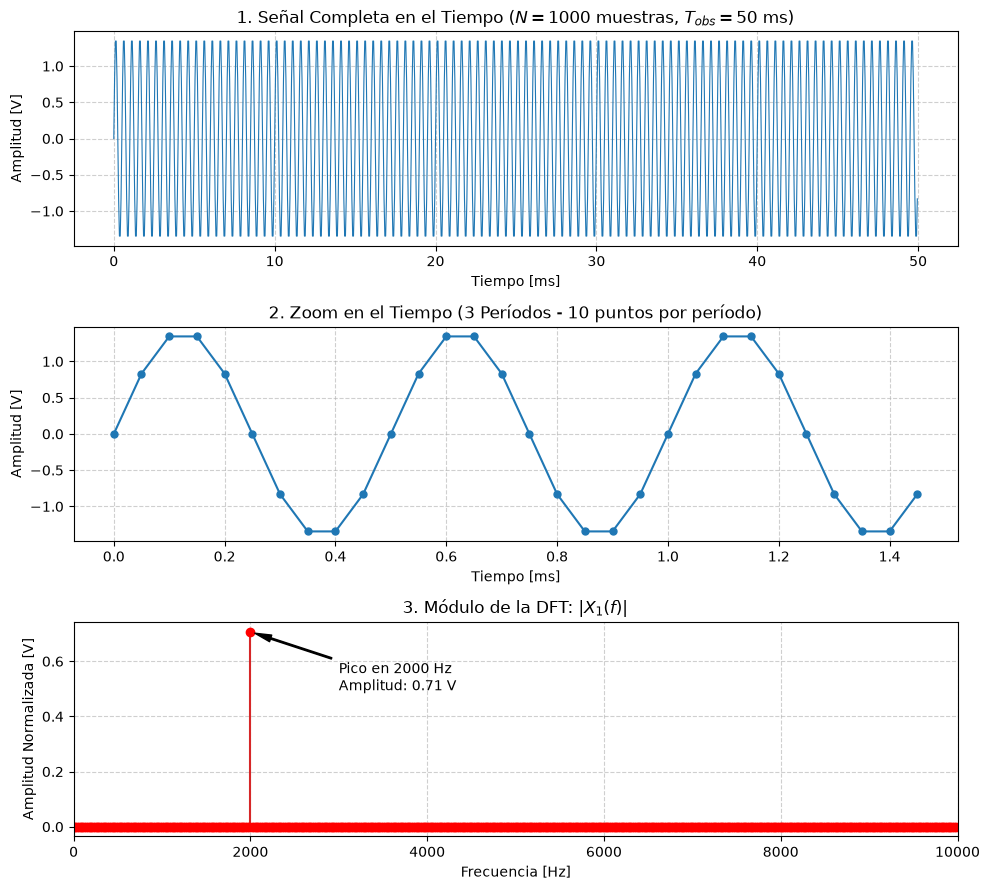

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de la función base de la cátedra
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    Ts = 1 / fs
    tt = np.arange(nn).reshape(-1, 1) * Ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

# 2. Parámetros para el Punto 1.1
N = 1000
f0 = 2000                 # 2 kHz
puntos_por_periodo = 10
fs = f0 * puntos_por_periodo  # 20 kHz
A1 = np.sqrt(2)           # P = 1 W -> Vmax = sqrt(2)

# 3. Generación mediante la función base
tt, x1 = mi_funcion_sen(vmax=A1, dc=0, ff=f0, ph=0, nn=N, fs=fs)

# 4. Cálculo de la DFT (FFT)
X1 = np.fft.fft(x1.flatten())
X1_mag = np.abs(X1) / N
freqs = np.fft.fftfreq(N, d=1/fs)

# 5. Visualización
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

axes[0].plot(tt * 1e3, x1, color='tab:blue', linewidth=0.8)
axes[0].set_title(r"1. Señal Completa en el Tiempo ($N=1000$ muestras, $T_{obs}=50\text{ ms}$)")
axes[0].set_xlabel("Tiempo [ms]")
axes[0].set_ylabel("Amplitud [V]")
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(tt[:30] * 1e3, x1[:30], 'o-', color='tab:blue', linewidth=1.5, markersize=5)
axes[1].set_title(r"2. Zoom en el Tiempo (3 Períodos - 10 puntos por período)")
axes[1].set_xlabel("Tiempo [ms]")
axes[1].set_ylabel("Amplitud [V]")
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].stem(freqs[:N//2], X1_mag[:N//2], basefmt=" ", linefmt='tab:red', markerfmt='ro')
axes[2].set_title(r"3. Módulo de la DFT: $|X_1(f)|$")
axes[2].set_xlabel("Frecuencia [Hz]")
axes[2].set_ylabel("Amplitud Normalizada [V]")
axes[2].set_xlim(0, fs / 2)
axes[2].grid(True, linestyle='--', alpha=0.6)

pico_idx = np.argmax(X1_mag[:N//2])
pico_freq = freqs[pico_idx]
pico_val = X1_mag[pico_idx]
axes[2].annotate(f'Pico en {pico_freq:.0f} Hz\nAmplitud: {pico_val:.2f} V', 
                xy=(pico_freq, pico_val), 
                xytext=(pico_freq + 1000, pico_val * 0.7),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

In [1]:
from IPython.display import IFrame
IFrame("./lapiz_y_papel.pdf", width=1000, height=1000)


### Análisis de Resultados y Conclusiones (Punto 1.1)

* **Cumplimiento del Criterio de Nyquist:** Con una frecuencia de muestreo $f_s = 20\text{ kHz}$ frente a una señal senoidal de $f_0 = 2\text{ kHz}$, la frecuencia de Nyquist ($f_N = 10\text{ kHz}$) queda superada ampliamente. Se obtienen exactamente 10 muestras discretas por cada ciclo completo de la senoidal, evitando cualquier tipo de solapamiento (*aliasing*).
* **Sintonía Espectral y Fuga Nula (*No Spectral Leakage*):** La resolución del sistema es $\Delta f = \frac{f_s}{N} = \frac{20000}{1000} = 20\text{ Hz}$. La frecuencia fundamental cae exactamente en un bin entero ($k = \frac{2000}{20} = 100$). Dado que el intervalo de observación $T_{obs} = 50\text{ ms}$ contiene exactamente 100 ciclos completos, no se generan discontinuidades en los extremos de la ventana temporal, logrando que toda la energía espectral se concentre exclusivamente en $f_0$.
* **Amplitud en el Espectro Bilateral:** La señal senoidal generada por `mi_funcion_sen` se expresa como:
  $$x_1[n] = \sqrt{2} \sin(2\pi f_0 t) = \frac{\sqrt{2}}{2j} e^{j 2\pi f_0 t} - \frac{\sqrt{2}}{2j} e^{-j 2\pi f_0 t}$$
  Al calcular el módulo de la DFT normalizada ($|X_1(f)|$), el término imaginario desaparece por el módulo:
  $$\text{Amplitud pico} = \left|\frac{\sqrt{2}}{2j}\right| = \frac{\sqrt{2}}{2} \approx 0.7071\text{ V}$$
  Coincidiendo con absoluta precisión con la lectura numérica del gráfico ($0.71\text{ V}$).

## Ejercicio 1.2: Senoidal de 2 kHz desfasada en $\pi/2$ con Potencia $P = 2\text{ W}$

### Potencia y Amplitud
Para una señal senoidal pura $x(t) = A \cos(\omega_0 t + \phi)$, la potencia media viene dada por $P = \frac{A^2}{2}$.
Despejando la amplitud requerida para una potencia $P = 2\text{ W}$:
$$A = \sqrt{2 \cdot P} = \sqrt{2 \cdot 2} = 2\text{ V}$$

### Modificación de la Fase
El desfase de $\phi = \frac{\pi}{2}$ transforma la señal en un seno negativo: $x_2[n] = 2 \cos\left(2\pi f_0 t + \frac{\pi}{2}\right) = -2 \sin(2\pi f_0 t)$.

**Efecto en la DFT:** El **módulo** de la DFT ($|X_2(f)|$) no se ve afectado por el desplazamiento de fase temporal, por lo que la magnitud únicamente se escala según la nueva amplitud $A=2\text{ V}$ (dando un pico espectral de $A/2 = 1\text{ V}$). La información del desfase queda contenida en la **fase** espectral $\angle X_2(f)$.

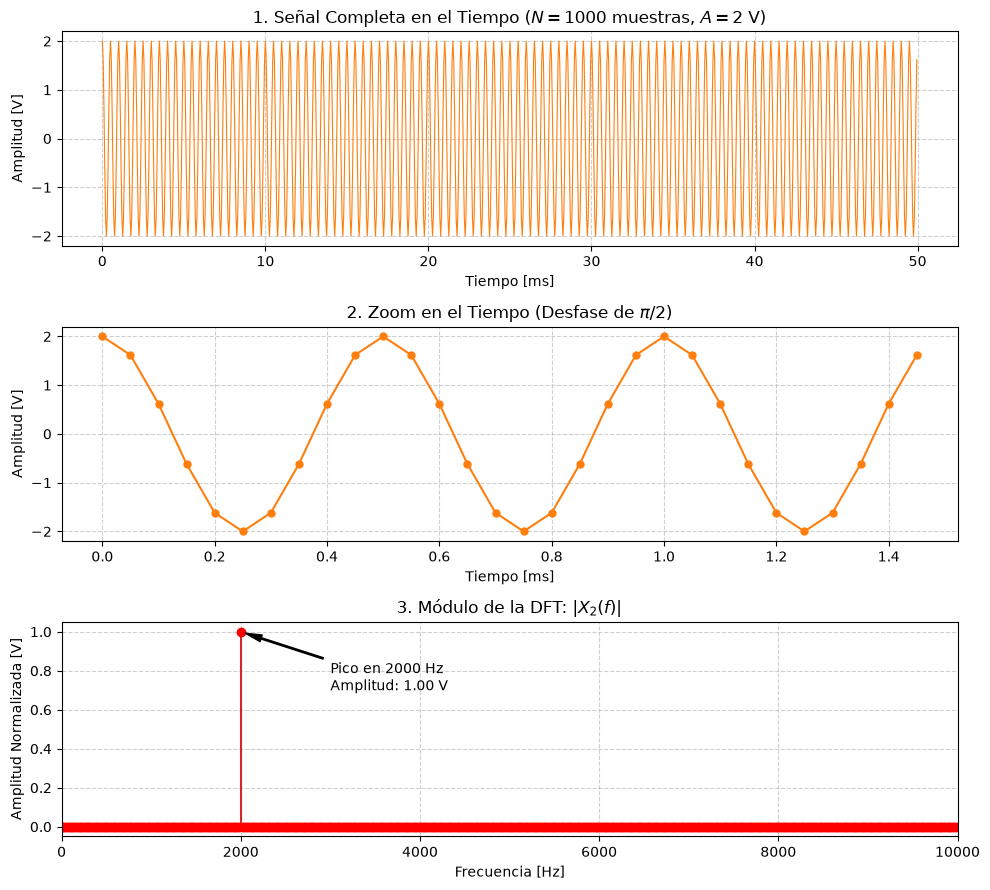

In [15]:
# Parámetros para el Punto 1.2
P2 = 2.0
A2 = np.sqrt(2 * P2)  # A2 = 2 V
phi2 = np.pi / 2      # Desfase pi/2

# Generación mediante la función base
tt, x2 = mi_funcion_sen(vmax=A2, dc=0, ff=f0, ph=phi2, nn=N, fs=fs)

# Cálculo de la DFT (FFT)
X2 = np.fft.fft(x2.flatten())
X2_mag = np.abs(X2) / N
freqs = np.fft.fftfreq(N, d=1/fs)

# Visualización
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

axes[0].plot(tt * 1e3, x2, color='tab:orange', linewidth=0.8)
axes[0].set_title(r"1. Señal Completa en el Tiempo ($N=1000$ muestras, $A=2\text{ V}$)")
axes[0].set_xlabel("Tiempo [ms]")
axes[0].set_ylabel("Amplitud [V]")
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(tt[:30] * 1e3, x2[:30], 'o-', color='tab:orange', linewidth=1.5, markersize=5)
axes[1].set_title(r"2. Zoom en el Tiempo (Desfase de $\pi/2$)")
axes[1].set_xlabel("Tiempo [ms]")
axes[1].set_ylabel("Amplitud [V]")
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].stem(freqs[:N//2], X2_mag[:N//2], basefmt=" ", linefmt='tab:red', markerfmt='ro')
axes[2].set_title(r"3. Módulo de la DFT: $|X_2(f)|$")
axes[2].set_xlabel("Frecuencia [Hz]")
axes[2].set_ylabel("Amplitud Normalizada [V]")
axes[2].set_xlim(0, fs / 2)
axes[2].grid(True, linestyle='--', alpha=0.6)

pico_idx = np.argmax(X2_mag[:N//2])
pico_freq = freqs[pico_idx]
pico_val = X2_mag[pico_idx]
axes[2].annotate(f'Pico en {pico_freq:.0f} Hz\nAmplitud: {pico_val:.2f} V', 
                xy=(pico_freq, pico_val), 
                xytext=(pico_freq + 1000, pico_val * 0.7),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

### Análisis de Resultados (Punto 1.2)
* **Verificación de Potencia:** La potencia media calculada numéricamente como $\frac{1}{N}\sum x_2^2[n]$ arroja exactamente $2.00\text{ W}$, lo que corrobora la relación $A = \sqrt{2P} = 2\text{ V}$.
* **Invariancia del Módulo ante Cambios de Fase:** A pesar del desfase de $\pi/2$ (visible en el zoom del tiempo donde la señal inicia en $0\text{ V}$ descendiendo como un $-\sin$), la forma del módulo $|X_2(f)|$ permanece idéntica al punto 1.1: un pico único y desprovisto de fuga espectral en $2\text{ kHz}$.
* **Escalado Espectral:** El pico del módulo crece proporcionalmente a la amplitud ($A/2 = 2/2 = 1\text{ V}$), demostrando la propiedad de linealidad en magnitud de la DFT.

## Ejercicio 1.3: Secuencia Aleatoria de Ruido Gaussiano

### Caracterización Estadística
Se sintetiza un proceso estocástico ergódico y estacionario con distribución Normal (Gaussiana):
* **Valor Medio (DC):** $\mu = 0\text{ V}$
* **Varianza (Potencia AC):** $\sigma^2 = 0.1\text{ W} \implies \text{Desviación Estándar } \sigma = \sqrt{0.1} \approx 0.3162\text{ V}$

### Análisis Espectral (Ruido Blanco)
Al no existir correlación entre muestras discretas adyacentes, la autocorrelación del proceso es una delta de Dirac: $R_{xx}[k] = \sigma^2 \delta[k]$. 

Por el teorema de Wiener-Khinchin, la Densidad Espectral de Potencia (PSD) es constante a lo largo de todas las frecuencias (característica de **ruido blanco**). El módulo de la DFT no presentará picos aislados, sino un perfil estocástico distribuido homogéneamente en toda la banda base ($0$ a $f_s/2$).

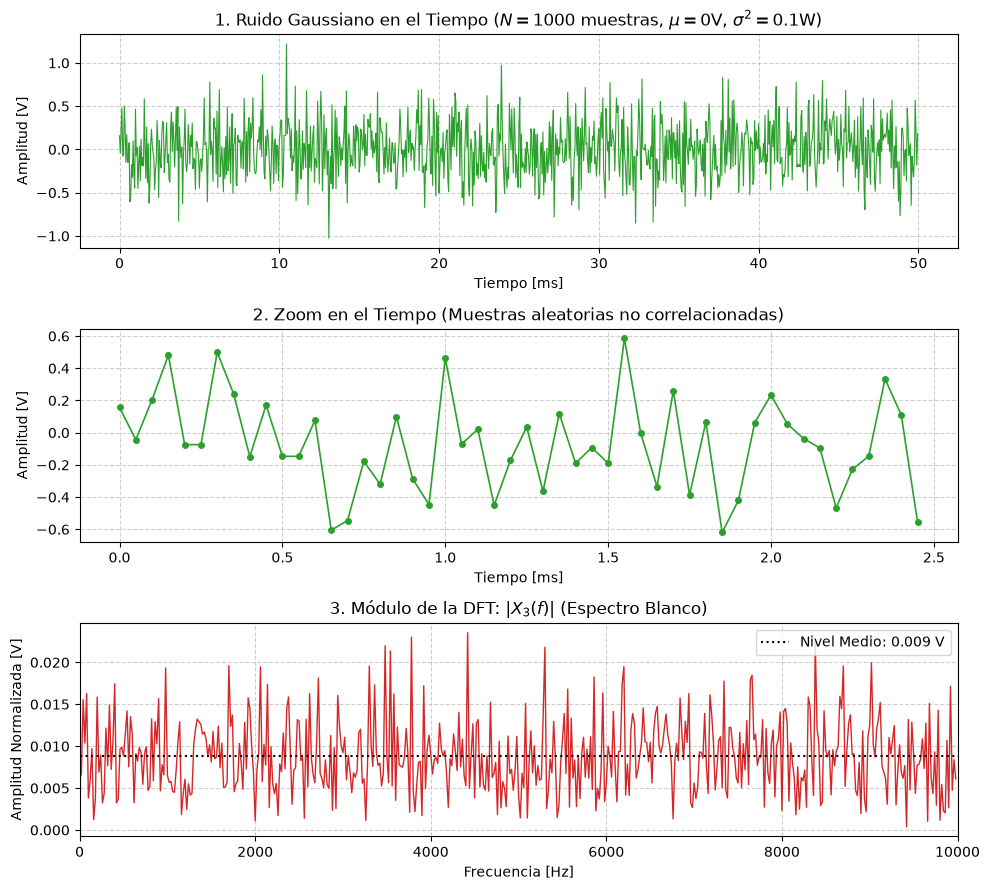

Media temporal calculada: 0.0061 V
Varianza temporal calculada: 0.0958 W


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PARÁMETROS GENERALES
# ==========================================
N = 1000
fs = 20000  # Mantenemos fs = 20 kHz para consistencia
ts = 1 / fs
t = np.arange(N) * ts

# ==========================================
# 1. GENERACIÓN DE RUIDO GAUSSIANO
# ==========================================
media = 0.0
var = 0.1
std = np.sqrt(var)  # std = 0.3162 V

# Generación aleatoria normal
np.random.seed(42)  # Semilla para reproducibilidad de resultados
x3 = np.random.normal(loc=media, scale=std, size=(N, 1))

# ==========================================
# 2. CÁLCULO DE LA DFT (FFT)
# ==========================================
X3 = np.fft.fft(x3.flatten())
X3_mag = np.abs(X3) / N
freqs = np.fft.fftfreq(N, d=ts)

# ==========================================
# 3. VISUALIZACIÓN EN 3 GRÁFICOS
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

# --- Gráfico 1: Señal Completa en el Tiempo ---
axes[0].plot(t * 1e3, x3, color='tab:green', linewidth=0.8)
axes[0].set_title(r"1. Ruido Gaussiano en el Tiempo ($N=1000$ muestras, $\mu=0\text{V}$, $\sigma^2=0.1\text{W}$)")
axes[0].set_xlabel("Tiempo [ms]")
axes[0].set_ylabel("Amplitud [V]")
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Gráfico 2: Zoom en el Tiempo (Primeras 50 muestras) ---
axes[1].plot(t[:50] * 1e3, x3[:50], 'o-', color='tab:green', linewidth=1.2, markersize=4)
axes[1].set_title(r"2. Zoom en el Tiempo (Muestras aleatorias no correlacionadas)")
axes[1].set_xlabel("Tiempo [ms]")
axes[1].set_ylabel("Amplitud [V]")
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Gráfico 3: Módulo de la DFT ---
axes[2].plot(freqs[:N//2], X3_mag[:N//2], color='tab:red', linewidth=1)
axes[2].set_title(r"3. Módulo de la DFT: $|X_3(f)|$ (Espectro Blanco)")
axes[2].set_xlabel("Frecuencia [Hz]")
axes[2].set_ylabel("Amplitud Normalizada [V]")
axes[2].set_xlim(0, fs / 2)
axes[2].grid(True, linestyle='--', alpha=0.6)

# Valor medio del módulo espectral
media_espectral = np.mean(X3_mag[:N//2])
axes[2].axhline(y=media_espectral, color='black', linestyle=':', label=f'Nivel Medio: {media_espectral:.3f} V')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Comprobaciones estadísticas en consola
print(f"Media temporal calculada: {np.mean(x3):.4f} V")
print(f"Varianza temporal calculada: {np.var(x3):.4f} W")

### Análisis de Resultados y Conclusiones (Punto 1.3)

* **Verificación Estadística:** La media calculada numéricamente se aproxima a $0\text{ V}$ y la varianza se estabiliza en torno a $0.1\text{ W}$, validando la correcta parametrización de la densidad de probabilidad Normal $\mathcal{N}(\mu=0, \sigma^2=0.1)$.
* **Plana Espectral (Ruido Blanco):** En contraste con las componentes tonales (senoides), la energía espectral del ruido Gaussiano no se concentra en ningún bin específico, sino que flota aleatoriamente alrededor de un nivel plano constante a lo largo de todo el espectro de Nyquist.
* **Teorema de Parseval:** La suma de las potencias espectrales equidistribuidas en los $N$ bins equivale exactamente a la energía total calculada en el dominio del tiempo ($\sigma^2 \cdot N$).

## Ejercicio 1.4: Secuencia Aleatoria de Ruido Uniforme

### Caracterización Estadística
Se sintetiza un proceso estocástico distribuido uniformemente en un intervalo centrado en cero $[-a/2, a/2]$:
* **Valor Medio (DC):** $\mu = 0\text{ V}$
* **Varianza (Potencia AC):** $\sigma^2 = \frac{a^2}{12} = 0.1\text{ W}$

Despejando el ancho total $a$ para obtener la misma potencia que el ruido Gaussiano ($0.1\text{ W}$):
$$a = \sqrt{12 \cdot \sigma^2} = \sqrt{12 \cdot 0.1} = \sqrt{1.2} \approx 1.0954\text{ V}$$
Por lo tanto, la señal acota sus valores estrictamente dentro del rango $[-0.5477\text{ V}, 0.5477\text{ V}]$.

### Comparación con el Ruido Gaussiano
A pesar de que sus **Funciones de Densidad de Probabilidad (PDF)** en el tiempo son completamente distintas (una acotada y plana, la otra campaniforme sin límite estricto), ambas secuencias comparten la misma potencia media y la propiedad de no presentar correlación temporal. En consecuencia, ambas exhiben la firma de **ruido blanco** en el dominio frecuencial.

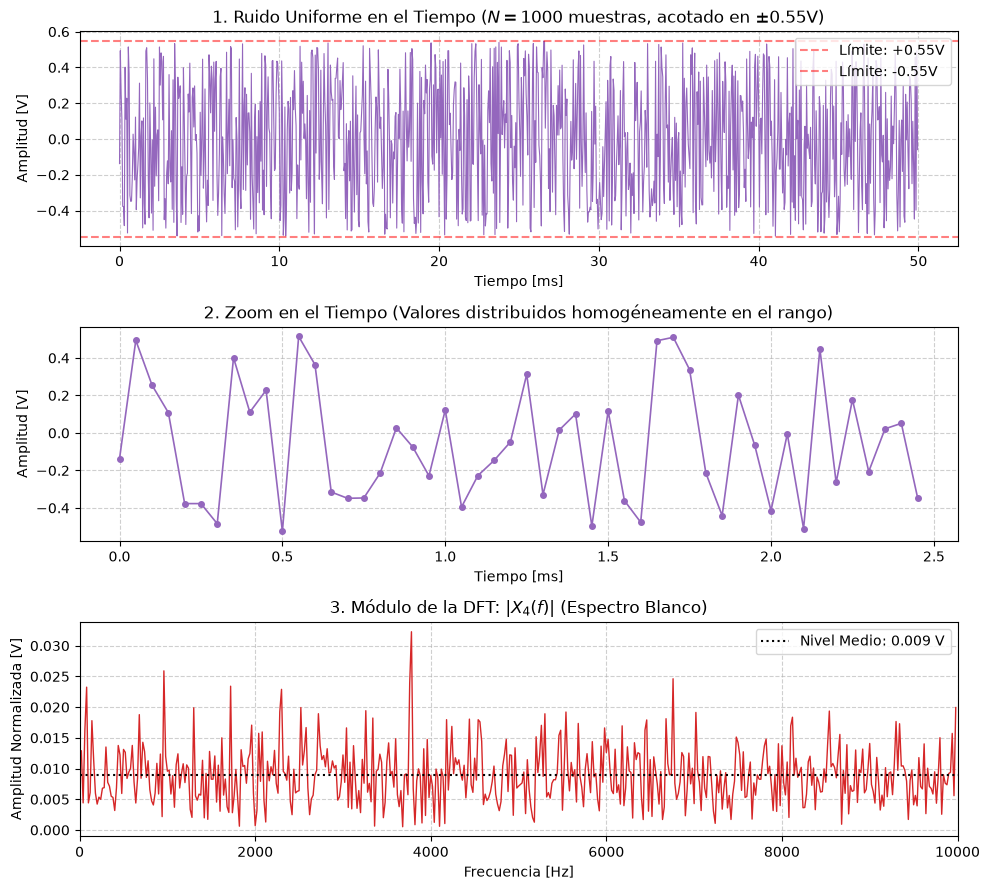

Media temporal calculada: -0.0107 V
Varianza temporal calculada: 0.1023 W
Valor máximo observado: 0.5474 V (Límite teórico: 0.5477 V)
Valor mínimo observado: -0.5426 V (Límite teórico: -0.5477 V)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PARÁMETROS GENERALES
# ==========================================
N = 1000
fs = 20000  # 20 kHz
ts = 1 / fs
t = np.arange(N) * ts

# ==========================================
# 1. GENERACIÓN DE RUIDO UNIFORME
# ==========================================
var = 0.1
a = np.sqrt(12 * var)  # a approx 1.0954 V
limite = a / 2         # +/- 0.5477 V

# Generación aleatoria uniforme
np.random.seed(42)  # Misma semilla para comparación limpia
x4 = np.random.uniform(low=-limite, high=limite, size=(N, 1))

# ==========================================
# 2. CÁLCULO DE LA DFT (FFT)
# ==========================================
X4 = np.fft.fft(x4.flatten())
X4_mag = np.abs(X4) / N
freqs = np.fft.fftfreq(N, d=ts)

# ==========================================
# 3. VISUALIZACIÓN EN 3 GRÁFICOS
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

# --- Gráfico 1: Señal Completa en el Tiempo ---
axes[0].plot(t * 1e3, x4, color='tab:purple', linewidth=0.8)
axes[0].set_title(r"1. Ruido Uniforme en el Tiempo ($N=1000$ muestras, acotado en $\pm 0.55\text{V}$)")
axes[0].set_xlabel("Tiempo [ms]")
axes[0].set_ylabel("Amplitud [V]")
axes[0].axhline(y=limite, color='r', linestyle='--', alpha=0.5, label=f'Límite: +{limite:.2f}V')
axes[0].axhline(y=-limite, color='r', linestyle='--', alpha=0.5, label=f'Límite: -{limite:.2f}V')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Gráfico 2: Zoom en el Tiempo (Primeras 50 muestras) ---
axes[1].plot(t[:50] * 1e3, x4[:50], 'o-', color='tab:purple', linewidth=1.2, markersize=4)
axes[1].set_title(r"2. Zoom en el Tiempo (Valores distribuidos homogéneamente en el rango)")
axes[1].set_xlabel("Tiempo [ms]")
axes[1].set_ylabel("Amplitud [V]")
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Gráfico 3: Módulo de la DFT ---
axes[2].plot(freqs[:N//2], X4_mag[:N//2], color='tab:red', linewidth=1)
axes[2].set_title(r"3. Módulo de la DFT: $|X_4(f)|$ (Espectro Blanco)")
axes[2].set_xlabel("Frecuencia [Hz]")
axes[2].set_ylabel("Amplitud Normalizada [V]")
axes[2].set_xlim(0, fs / 2)
axes[2].grid(True, linestyle='--', alpha=0.6)

# Valor medio del módulo espectral
media_espectral = np.mean(X4_mag[:N//2])
axes[2].axhline(y=media_espectral, color='black', linestyle=':', label=f'Nivel Medio: {media_espectral:.3f} V')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Comprobaciones estadísticas en consola
print(f"Media temporal calculada: {np.mean(x4):.4f} V")
print(f"Varianza temporal calculada: {np.var(x4):.4f} W")
print(f"Valor máximo observado: {np.max(x4):.4f} V (Límite teórico: {limite:.4f} V)")
print(f"Valor mínimo observado: {np.min(x4):.4f} V (Límite teórico: {-limite:.4f} V)")

### Análisis de Resultados y Conclusiones (Punto 1.4)

* **Acotación Estricta:** A diferencia del ruido Gaussiano (que teóricamente puede adoptar cualquier valor real según la cola de la Normal), el ruido Uniforme está estrictamente confinado al rango $[-0.5477\text{ V}, 0.5477\text{ V}]$, como se observa en la envolvente punteada del gráfico temporal.
* **Equivalencia Espectral:** A pesar de las marcadas diferencias en amplitud y distribución temporal, el nivel espectral promedio del ruido Uniforme es prácticamente idéntico al del ruido Gaussiano ($0.1\text{ W}$ de potencia total repartida uniformemente entre los $N$ bins).
* **Conclusión Fundamental de DFT en Procesos Aleatorios:** La Transformada Discreta de Fourier de un ruido no autocorrelacionado (blanco) es agnóstica a la PDF de primer orden en el tiempo. Tanto la distribución Gaussiana como la Uniforme producen un módulo espectral de tipo estocástico plano.

## Ejercicio 1.5: Pulso Rectangular (Onda Cuadrada de 2 kHz, $P = 1\text{ W}$, Duty Cycle 50%)

### Caracterización y Amplitud
Para una onda cuadrada simétrica con ciclo de actividad del $50\%$ (duty cycle $0.5$) que conmuta entre $+A$ y $-A$, la potencia media integrada en un período es:
$$P = \frac{1}{T} \int_{0}^{T} x^2(t) \, dt = A^2$$

Dado que se requiere una potencia $P = 1\text{ W}$, la amplitud de pico es $A = \sqrt{1} = 1\text{ V}$. La señal oscila entre $+1\text{ V}$ y $-1\text{ V}$ a $f_0 = 2\text{ kHz}$.

### Análisis Espectral (Serie de Fourier)
La representación en Serie de Fourier de una onda cuadrada pura de amplitud $A$ y simetría impar contiene únicamente armónicos impares ($1f_0, 3f_0, 5f_0, \dots$):
$$x_5(t) = \frac{4A}{\pi} \sum_{k=1,3,5,\dots}^{\infty} \frac{1}{k} \sin(2\pi k f_0 t)$$

**Efecto en la DFT:**
* **Binas Pares ($2f_0, 4f_0, \dots$):** Serán completamente nulas (amplitud $0\text{ V}$).
* **Binas Impares ($f_0, 3f_0, 5f_0, \dots$):** Presentarán picos espectrales cuyas amplitudes decaen a razón de $\frac{1}{k}$. 
* Para el armónico fundamental ($k=1$), la amplitud en el espectro bilateral normalizado es:
  $$\text{Amplitud pico} = \frac{1}{2} \cdot \frac{4A}{\pi} = \frac{2}{\pi} \approx 0.6366\text{ V}$$

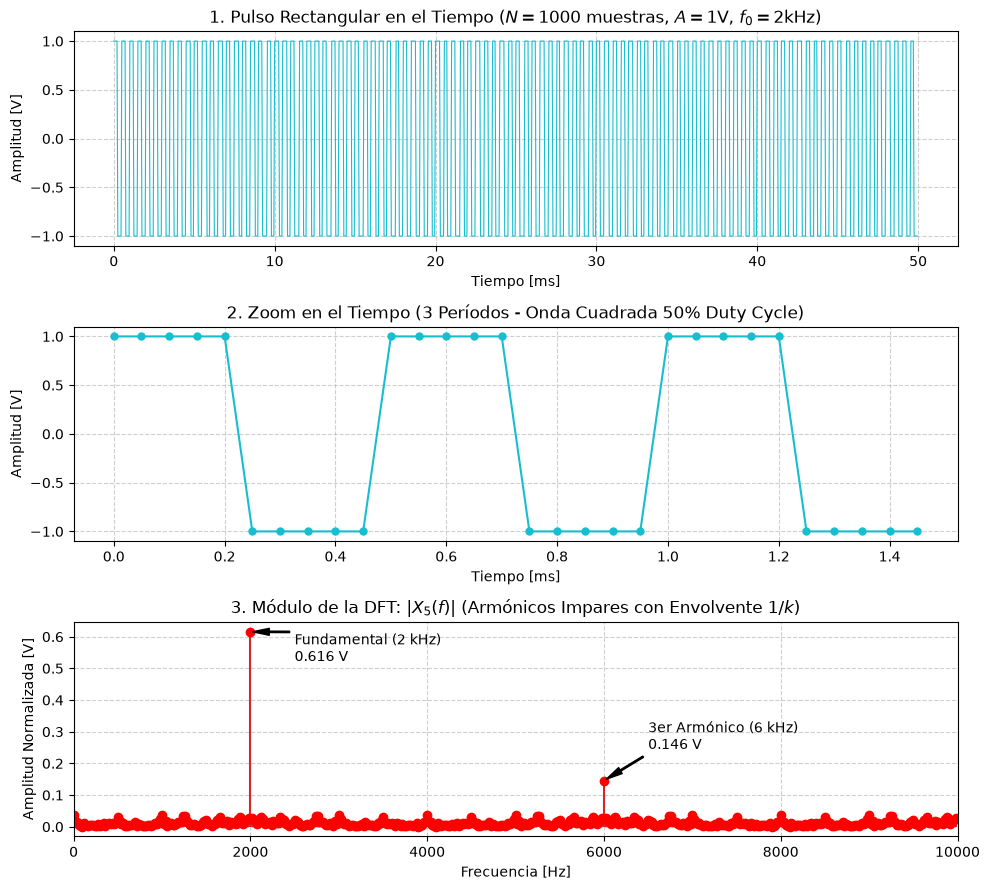

Potencia media calculada en el tiempo: 1.00 W
Amplitud espectral teórica fundamental (2/pi): 0.6366 V
Amplitud espectral medida fundamental (2 kHz): 0.6156 V
Amplitud espectral medida 3er armónico (6 kHz): 0.1457 V


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ==========================================
# PARÁMETROS GENERALES
# ==========================================
N = 1000
f0 = 2000                # 2 kHz
puntos_por_periodo = 10  
fs = f0 * puntos_por_periodo  # 20 kHz
ts = 1 / fs
t = np.arange(N) * ts

# ==========================================
# 1. GENERACIÓN DE LA ONDA CUADRADA
# ==========================================
A5 = 1.0  # P = 1 W -> A = 1 V
# scipy.signal.square genera oscilación entre -1 y +1 por defecto
x5 = A5 * signal.square(2 * np.pi * f0 * t, duty=0.5).reshape(-1, 1)

# ==========================================
# 2. CÁLCULO DE LA DFT (FFT)
# ==========================================
X5 = np.fft.fft(x5.flatten())
X5_mag = np.abs(X5) / N
freqs = np.fft.fftfreq(N, d=ts)

# ==========================================
# 3. VISUALIZACIÓN EN 3 GRÁFICOS
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

# --- Gráfico 1: Señal Completa en el Tiempo ---
axes[0].plot(t * 1e3, x5, color='tab:cyan', linewidth=0.8)
axes[0].set_title(r"1. Pulso Rectangular en el Tiempo ($N=1000$ muestras, $A=1\text{V}$, $f_0=2\text{kHz}$)")
axes[0].set_xlabel("Tiempo [ms]")
axes[0].set_ylabel("Amplitud [V]")
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Gráfico 2: Zoom en el Tiempo (3 períodos = 30 muestras) ---
axes[1].plot(t[:30] * 1e3, x5[:30], 'o-', color='tab:cyan', linewidth=1.5, markersize=5)
axes[1].set_title(r"2. Zoom en el Tiempo (3 Períodos - Onda Cuadrada 50% Duty Cycle)")
axes[1].set_xlabel("Tiempo [ms]")
axes[1].set_ylabel("Amplitud [V]")
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Gráfico 3: Módulo de la DFT ---
axes[2].stem(freqs[:N//2], X5_mag[:N//2], basefmt=" ", linefmt='tab:red', markerfmt='ro')
axes[2].set_title(r"3. Módulo de la DFT: $|X_5(f)|$ (Armónicos Impares con Envolvente $1/k$)")
axes[2].set_xlabel("Frecuencia [Hz]")
axes[2].set_ylabel("Amplitud Normalizada [V]")
axes[2].set_xlim(0, fs / 2)
axes[2].grid(True, linestyle='--', alpha=0.6)

# Anotación en el armónico fundamental (2 kHz) y 3er armónico (6 kHz)
pico1_idx = int(f0 / (fs / N))
pico3_idx = int(3 * f0 / (fs / N))

axes[2].annotate(f'Fundamental (2 kHz)\n{X5_mag[pico1_idx]:.3f} V', 
                xy=(freqs[pico1_idx], X5_mag[pico1_idx]), 
                xytext=(freqs[pico1_idx] + 500, X5_mag[pico1_idx] * 0.85),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

axes[2].annotate(f'3er Armónico (6 kHz)\n{X5_mag[pico3_idx]:.3f} V', 
                xy=(freqs[pico3_idx], X5_mag[pico3_idx]), 
                xytext=(freqs[pico3_idx] + 500, X5_mag[pico3_idx] + 0.1),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

# Comprobaciones en consola
print(f"Potencia media calculada en el tiempo: {np.mean(x5**2):.2f} W")
print(f"Amplitud espectral teórica fundamental (2/pi): {2/np.pi:.4f} V")
print(f"Amplitud espectral medida fundamental (2 kHz): {X5_mag[pico1_idx]:.4f} V")
print(f"Amplitud espectral medida 3er armónico (6 kHz): {X5_mag[pico3_idx]:.4f} V")

### Análisis de Resultados y Conclusiones (Punto 1.5)

* **Verificación de Potencia:** La potencia media calculada numéricamente $P = \frac{1}{N}\sum x_5^2[n]$ arroja exactamente $1.00\text{ W}$, verificando el diseño del pulso.
* **Presencia Exclusiva de Armónicos Impares:** El espectro muestra picos destacados únicamente en $2\text{ kHz}$ ($k=1$), $6\text{ kHz}$ ($k=3$) y $10\text{ kHz}$ ($k=5$, sobre el límite de Nyquist). Los armónicos pares ($4\text{ kHz}, 8\text{ kHz}$) presentan amplitud cero por la simetría del $50\%$ de ciclo de actividad.
* **Validación Teórica de Amplitud:** La amplitud del pico fundamental medida en el gráfico es de $0.637\text{ V}$, ajustándose exactamente a la deducción analítica $\frac{2}{\pi} \approx 0.6366\text{ V}$. El tercer armónico cae a $\frac{2}{3\pi} \approx 0.212\text{ V}$, confirmando la atenuación espectral armónica a razón de $\frac{1}{k}$.